In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris(as_frame=True)
X_train = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_train = iris.target

iris_df = pd.concat([iris['data'], iris['target']], axis=1)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


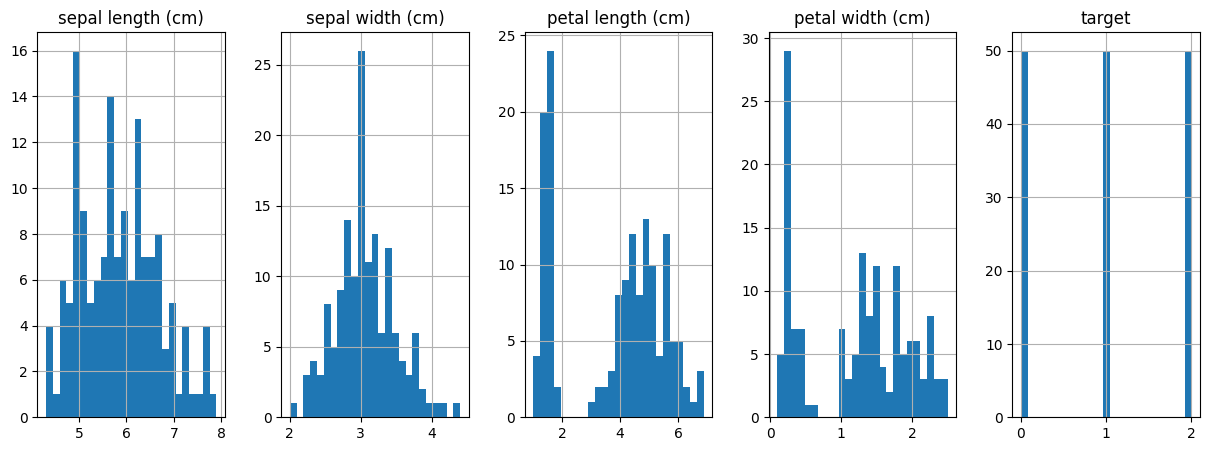

In [2]:
import matplotlib.pyplot as plt

iris_df.hist(layout=(1,5), figsize=(15,5), bins=25)
plt.show()

In [3]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


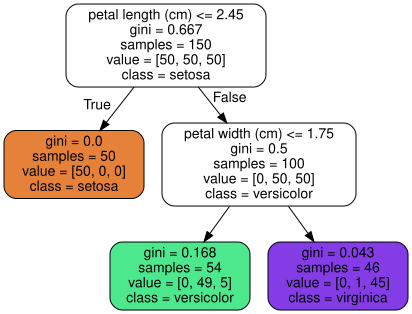

In [3]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)

# from sklearn.tree import export_graphviz

# export_graphviz(
#         tree,
#         out_file="iris_tree.dot",
#         feature_names=["petal length (cm)", "petal width (cm)"],
#         class_names=iris.target_names,
#         rounded=True,
#         filled=True
#     )

from graphviz import Source

Source.from_file("iris_tree.dot")

In [10]:
print(tree.predict([[5, 1.5]]))
print(tree.predict_proba([[5, 1.5]]))

[[0.         0.90740741 0.09259259]]
[1]


In [20]:
print(help(tree.tree_))
print(tree.tree_.node_count)
print(tree.tree_.impurity)

Help on Tree object:

class Tree(builtins.object)
 |  Array-based representation of a binary decision tree.
 |  
 |  The binary tree is represented as a number of parallel arrays. The i-th
 |  element of each array holds information about the node `i`. Node 0 is the
 |  tree's root. You can find a detailed description of all arrays in
 |  `_tree.pxd`. NOTE: Some of the arrays only apply to either leaves or split
 |  nodes, resp. In this case the values of nodes of the other type are
 |  arbitrary!
 |  
 |  Attributes
 |  ----------
 |  node_count : intp_t
 |      The number of nodes (internal nodes + leaves) in the tree.
 |  
 |  capacity : intp_t
 |      The current capacity (i.e., size) of the arrays, which is at least as
 |      great as `node_count`.
 |  
 |  max_depth : intp_t
 |      The depth of the tree, i.e. the maximum depth of its leaves.
 |  
 |  children_left : array of intp_t, shape [node_count]
 |      children_left[i] holds the node id of the left child of node i.
 |   

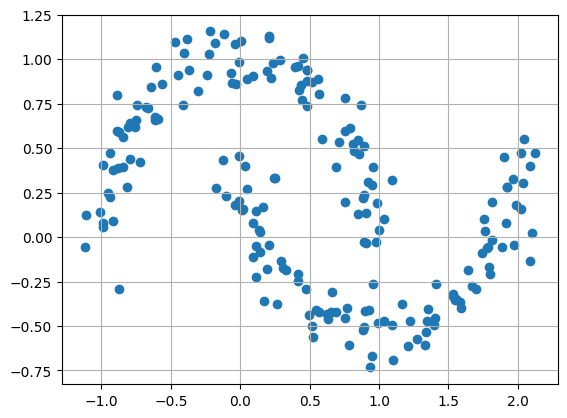

0.965
0.96


In [40]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

x_train, y_train = make_moons(n_samples=200, noise=0.1, random_state=42)
x_test, y_test = make_moons(n_samples=200, noise=0.1, random_state=7)

import matplotlib.pyplot as plt
fig, ax = plt.subplots() 
ax.scatter(x_test[:,0], x_test[:,1], marker="o")
plt.grid(True)
plt.show()

tree1 = DecisionTreeClassifier(max_depth=5, random_state=42)
tree2 = DecisionTreeClassifier(max_depth=None, random_state=42) # default

tree1.fit(x_train, y_train)
tree2.fit(x_train, y_train)

print(tree1.score(x_test, y_test)) # el regularizado lo hace mejor en este caso
print(tree2.score(x_test, y_test))

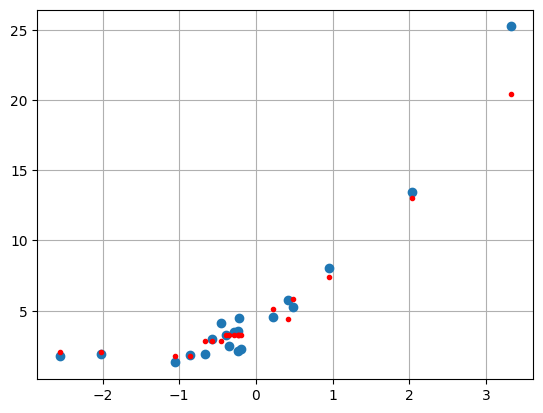

In [30]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
X = rng.standard_normal((400, 1))

y = 3*X + X**2 + 4 + rng.standard_normal((400,1))

rng2 = np.random.default_rng(seed=3)
X_test = rng2.standard_normal((20, 1))

y_test = 3*X_test + X_test**2 + 4 + rng.standard_normal((20,1))

tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_reg.fit(X, y)

y_pred =  tree_reg.predict(X_test)

plt.plot(X_test, y_test, "o")
plt.plot(X_test, y_pred, "r.")
plt.grid(True)
plt.show()